# ベイズ推論
- パラメータ推定の方法
    - *頻度論：最尤推定法（パラメータの点推定、局所解にはまりやすい）*
    - *ベイズ流：ベイズ推定（パラメータの分布推定、計算に時間がかかる、収束しない場合がある）*

## 環境構築

In [1]:
#%pip install -q graphviz

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib

%matplotlib inline

g++ not available, if using conda: `conda install gxx`


In [3]:
#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

## 推論

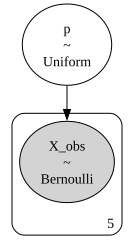

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [p]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [X_obs, p]
Sampling: [X_obs]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [18]:
#-----------------------------------------------
#問題設定
#-----------------------------------------------
"""
くじ引きを引いた際に、「アタリ|ハズレ|ハズレ|アタリ|ハズレ」であった。
1回のくじ引きに当たる確率をpとするとき、このpの値を求める。
"""

#-----------------------------------------------
#最尤推定法
#-----------------------------------------------
"""
def lp(p):
    return p ** 2 * (1-p) ** 3

p = np.arange(0, 1, 0.01)

plt.rcParams['figure.figsize'] = (6, 4)
plt.plot(p, lp(p))
plt.xlabel('p(確率値)')
plt.ylabel('尤度')
plt.title('尤度関数')
plt.show()
"""

#-----------------------------------------------
#ベイズ推定
#-----------------------------------------------
#乱数固定
random_seed=42

#観測値
X = np.array([1, 0, 0, 1, 0])

#コンテキスト定義
model11 = pm.Model()
with model11:
    #pm.Uniform：一様分布
    p = pm.Uniform('p', lower=0.0, upper=1.0)
    
    X_obs = pm.Bernoulli('X_obs', p=p, observed=X)

#図の意味について理解しておく
g = pm.model_to_graphviz(model11)
display(g)

#-----------------------------------------------
#サンプリング
#-----------------------------------------------
#パラメータを指定した場合

with model11:
    idata1_1 = pm.sample(
        #乱数系列の数
        chains=3,
        #捨てるサンプルの数
        tune=1000,
        #取得するサンプル数
        draws=2000,
        random_seed=random_seed)
    
    #事前分布サンプリングの追加    
    prior = pm.sample_prior_predictive(random_seed=random_seed)
    idata1_1['prior'] = prior.prior
    idata1_1['prior_predictive'] = prior.prior_predictive
    
    #事後分布サンプリングの追加
    pm.sample_posterior_predictive(idata1_1, random_seed=random_seed, extend_inferencedata=True)
    
    
    """参考：DataTree.groupsへのデータ追加は以下
    https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html#add-a-new-group-to-a-datatree
    """

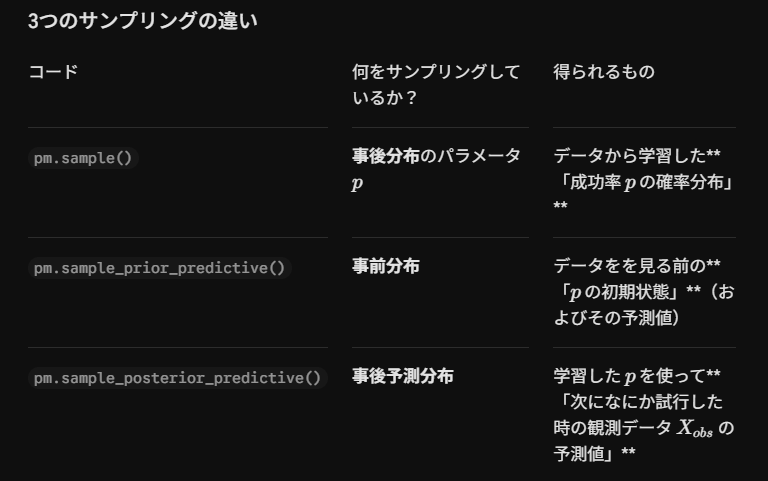

## 推論結果

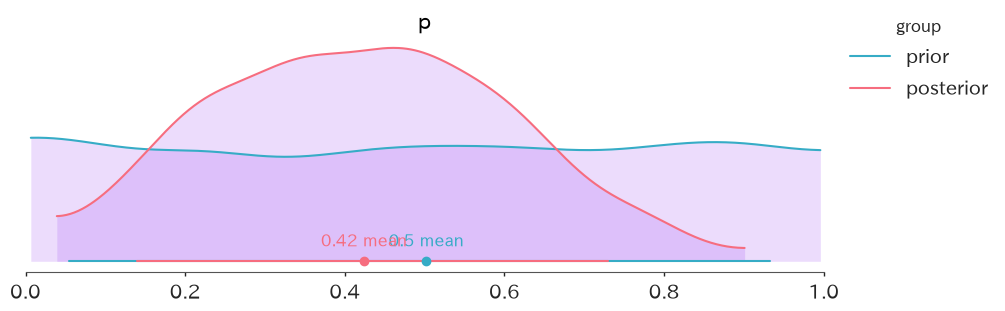

In [76]:
#-----------------------------------------------
#トレースプロットでチェーンごとのパラメータ収束を確認
#-----------------------------------------------
azp.style.use("arviz-variat")
azb.rcParams["stats.ci_prob"] = 0.9

# ax = azp.plot_trace_dist(idata1_1, compact=False, combined=False)

#-----------------------------------------------
#事前・事後分布をプロットしベイズ更新前後の分布の変化を確認
#priorが一様分布なのに対して事後分布では0.43を頂点とする山なりの分布に変化
#-----------------------------------------------
ax = azp.plot_prior_posterior(
    dt=idata1_1,
    var_names='p',
    kind='kde',
    backend='matplotlib',
    visuals={"credible_interval": True, #信頼区間
             "dist":True, #外郭の描画
             "face": {"alpha": 0.2, "color": "C5"}, #塗りつぶし
             "point_estimate_text": True,  # add the text of the point estimates
             "point_estimate": True,  # add the point estimates
             #"credible_interval": True,  # add the credible intervals
             },
    figure_kwargs={"figsize": (10, 3)},
    aes_by_visuals={
        #"kde": ["color"], # this is the default, so it can be omitted
        "point_estimate": ["color"],
        "credible_interval": ["color"],
    },
).get_viz("plot", "p").set_xlim(0, 1);

#-----------------------------------------------
#arviz_plots.plot_dist()
#-----------------------------------------------
# pc = azp.plot_dist(
#     idata1_1,
#     backend="matplotlib",
#     group="posterior",
#     aes={"color": ["p"]},
#     visuals={
#         "point_estimate": {"facecolor": "B0", "edgecolor": "B1", "width": 1.5},
#         "title": {"color": "B2"},
#     }
# )
# pc.show()


### 練習：二項分布のベイズ推論

In [78]:
#コンテキスト定義
model12 = pm.Model()

with model12:
    p = pm.Uniform('p', lower=0, upper=1)
    X_obs = pm.Binomial('X_obs', p=p, n=50, observed=20) #nは試行回数, observedはあたりの数
    
    ideta12 = pm.sample(
        #乱数系列の数
        chains=3,
        #捨てるサンプルの数
        tune=1000,
        #取得するサンプル数
        draws=2000,
        random_seed=random_seed
    )
    
    #事前分布と事後分布の予測値を追加
    ideta12['priror'] = pm.sample_prior_predictive(random_seed=random_seed).prior
    pm.sample_posterior_predictive(ideta12, random_seed=random_seed, extend_inferencedata=True)
    
#モデルの確認
g = pm.model_to_graphviz(model12)
#display(g)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [p]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [X_obs, p]
Sampling: [X_obs]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')